<a href="https://colab.research.google.com/github/madikabhavana-collab/ores5160-2026/blob/main/week9/week9assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Q1. Reading the CSV File (pandas + csv)

	1.	Use the csv module to open and print the first 5 rows of est2018-pop-res.csv.

	2.	Then use pandas.read_csv() to load the same file into a DataFrame.

	•	Display the shape (rows × columns).

	•	Print the list of column names.

	3.	Which column represents total population? Display the top 5 most populous states


In [1]:
import csv

with open('est2018-pop-res.csv', 'r') as file:
    reader = csv.reader(file)

    next(reader)  # skip header

    print("First 5 data rows:")
    for i, row in enumerate(reader):
        print(row)
        if i == 4:
            break

First 5 data rows:
['010', '0', '0', '00', 'United States', '327167434', '253768092', '77.6']
['040', '3', '6', '01', 'Alabama', '4887871', '3798031', '77.7']
['040', '4', '9', '02', 'Alaska', '737438', '553622', '75.1']
['040', '4', '8', '04', 'Arizona', '7171646', '5528989', '77.1']
['040', '3', '7', '05', 'Arkansas', '3013825', '2310645', '76.7']


In [2]:
import pandas as pd

df = pd.read_csv('est2018-pop-res.csv')

print("Shape (rows, columns):", df.shape)
print("Column names:", df.columns.tolist())

Shape (rows, columns): (53, 8)
Column names: ['SUMLEV', 'REGION', 'DIVISION', 'STATE', 'NAME', 'POPESTIMATE2018', 'POPEST18PLUS2018', 'PCNT_POPEST18PLUS']


In [3]:
# Remove United States row (important)
states_df = df[df['NAME'] != 'United States']

# Get top 5 most populous states
top5 = states_df.sort_values(by='POPESTIMATE2018', ascending=False).head(5)

print("Top 5 most populous states:")
print(top5[['NAME', 'POPESTIMATE2018']])

Top 5 most populous states:
            NAME  POPESTIMATE2018
5     California         39557045
44         Texas         28701845
10       Florida         21299325
33      New York         19542209
39  Pennsylvania         12807060


Q2. Basic Statistical Analysis (pandas)

	1.	Compute the average population across all states.

	2.	Find which region has the highest total population.

	3.	Plot a bar chart showing the population by region (use matplotlib)

In [4]:
# Average population across all states
average_population = states_df['POPESTIMATE2018'].mean()

print("Average population across all states:", average_population)

Average population across all states: 6353126.673076923


In [5]:
# Population by region
region_population = states_df.groupby('REGION')['POPESTIMATE2018'].sum()

print("Population by region:")
print(region_population)

print("Region with highest population:", region_population.idxmax())

Population by region:
REGION
1     56111079
2     68308744
3    124753948
4     77993663
X      3195153
Name: POPESTIMATE2018, dtype: int64
Region with highest population: 3


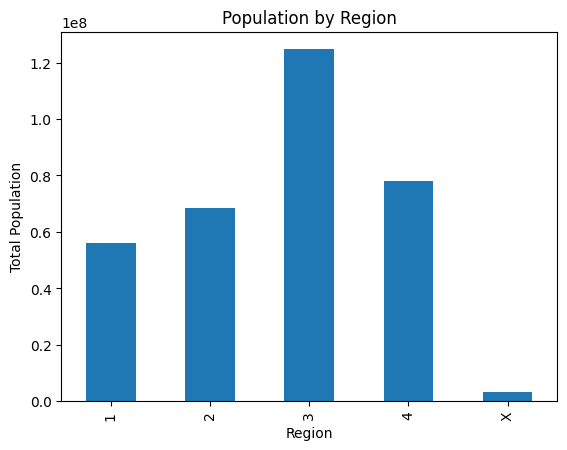

In [6]:
import matplotlib.pyplot as plt

region_population.plot(kind='bar')

plt.title("Population by Region")
plt.xlabel("Region")
plt.ylabel("Total Population")

plt.show()

Q3. Parsing the JSON File (FHIR structure)

Using json module:

	1.	Load patient.json into a Python dictionary.

	2.	Extract and print:

	•	Patient’s full official name

	•	Gender and birth date

	•	Current address (city, state, postal code)
  
	3.	Count how many phone numbers the patient has, and list their types (e.g., work, mobile, home).

In [7]:
import json

with open('patient.json', 'r') as file:
    patient = json.load(file)

In [8]:
name = patient['name'][0]  # first = official name
full_name = " ".join(name['given']) + " " + name['family']

print("Full Name:", full_name)

Full Name: Peter James Chalmers


In [9]:
print("Gender:", patient['gender'])
print("Birth Date:", patient['birthDate'])

Gender: male
Birth Date: 1974-12-25


In [10]:
address = patient['address'][0]

print("City:", address['city'])
print("State:", address['state'])
print("Postal Code:", address['postalCode'])

City: PleasantVille
State: Vic
Postal Code: 3999


In [11]:
telecom = patient['telecom']

print("Number of phone numbers:", len(telecom))

types = [t.get('use') for t in telecom]
print("Phone types:", types)

Number of phone numbers: 4
Phone types: ['home', 'work', 'mobile', 'old']
